# Title 
## Does Treatment-Related Change in Circadian Dinner Timing Explain Depression Improvement?

# Background
Seasonal affective disorder (SAD) is characterized by recurrent depressive episodes linked to seasonal changes in light exposure, circadian timing, and appetite-related factors (Rohan et al., 2009). Light therapy (LT), a first-line treatment for SAD, reliably produces antidepressant effects, yet the mechanisms underlying these effects remain incompletely understood (Wescott et al., 2026). LT is thought to act, in part, by shifting the timing of the central circadian clock, as indexed by dim light melatonin onset (DLMO; Terman et al., 2001; Lewy et al., 2006), thereby improving alignment with the external light–dark cycle (Carpenter et al., 2021). However, central circadian phase shifts alone may not fully capture how treatment influences mood, as phase shifts do not necessarily reflect alignment between the circadian system and daily behaviors. Depression is also associated with delayed and irregular meal timing (Mills et al., 2020), which may contribute to misalignment between behavioral rhythms and the light–dark cycle, as well as between central and peripheral physiological systems (Baron & Reid, 2014). Notably, SAD is characterized by atypical symptoms such as hyperphagia, carbohydrate craving, and hypersomnia, suggesting disruption in behavioral rhythms related to eating and sleep.

Alignment between eating behavior and central circadian phase may support mood regulation, but it is unclear whether changes in this alignment during treatment contribute to improvements in depression. Restricting food intake to the biological daytime—thereby maintaining alignment between central and peripheral rhythms—prevents adverse mood outcomes in shift workers (Chellappa et al., 2021), suggesting that circadian timing of eating may be important for affective regulation. However, whether treatments for SAD shift behavioral rhythms such as meal timing in parallel with circadian phase, or whether changes in alignment between eating behavior and circadian phase contributes to mood improvement has not been tested. While LT shifts central circadian phase, Cognitive Behavioral Therapy for SAD (CBT-SAD) may influence behavioral rhythms through changes in daily structure and activity scheduling. The present study therefore tests whether changes in circadian dinner timing (i.e., dinner timing relative to DLMO) mediate the relationship between treatment and depression outcomes.

If treatment influences central circadian phase (DLMO), and appetite is at least partially regulated by circadian processes, some individuals may experience coordinated shifts in both DLMO and meal timing. However, behavioral changes in meal timing may also occur independently of circadian phase shifts, or vice versa. Examining clock time of dinner provides a complementary perspective on behavioral timing that does not depend on circadian phase assessment. A secondary aim of the present study is to repeat analyses using clock time of dinner to determine whether behavioral timing alone, independent of circadian alignment, relates to changes in depressive symptoms. 

## Variables

### Participant and treatment variables

- `ID`: participant ID number
- `trt`: treatment group;
  - `1` = Light Therapy
  - `2` = CBT_SAD
- `TP`: numeric study timepoint in the main clinical/circadian dataset
  - `1` = baseline
  - `4` = mid-treatment
  - `7` = post-treatment
- `TIMEPT`: diary study timepoint
  - `Y1BASE` = Year 1 baseline
  - `Y1POST` = Year 1 post-treatment
- `Age`: participant age

### Circadian variables

- `DLMO_Fixed`: dim light melatonin onset, used as an estimate of endogenous central circadian phase, estimated at the point that melatonin crosses the fixed threshold of 3pg/mL

### Meal timing variables

- `DEC_Dinner`: diary-reported dinner time in decimal clock hours
- `dinner_clock`: average decimal dinner time within each participant and timepoint
- `dinner_dlmo`: dinner timing relative to DLMO, calculated as `dinner_clock - DLMO_dynamic`

### Depression variables

- `ss`: SIGH-SAD total depression score
- `ham`: Hamilton depression subscale from the SIGH-SAD
- `atyp`: atypical depression subscale
- `bdi`: Beck Depression Inventory-II score

### Derived change-score variables

- `delta_dinner_dlmo`: Year 1 post-treatment dinner-DLMO alignment - Year 1 baseline dinner-DLMO alignment
- `delta_dinner_clock`: Year 1 post-treatment dinner clock time - Year 1 baseline dinner clock time
- `delta_dlmo`: Year 1 post-treatment DLMO - Year 1 baseline DLMO
- `delta_ss`: Year 1 post-treatment SIGH-SAD - Year 1 baseline SIGH-SAD
- `delta_bdi`: Year 1 post-treatment BDI - Year 1 baseline BDI

Negative depression change scores indicate symptom improvement.

## Research Question

Does treatment group predict pre-to-post change in dinner timing relative to DLMO, and does this change in dinner-DLMO alignment predict pre-to-post change in depression severity?

## Hypotheses

The primary hypothesis is that treatment-related improvement in depressive symptoms will be statistically mediated by changes in circadian dinner timing. 

As a secondary comparison, I test whether change in clock-time dinner timing, rather than dinner timing relative to DLMO, mediates treatment-related depression improvement.

## Primary mediation model:

\[
Treatment \rightarrow \Delta DinnerDLMO \rightarrow \Delta Depression
\]

Path a tests whether treatment predicts change in dinner-DLMO alignment:

\[
\Delta DinnerDLMO = a(Treatment) + covariates
\]

Path b tests whether change in dinner-DLMO alignment predicts change in depression severity while controlling for treatment:

\[
\Delta Depression = b(\Delta DinnerDLMO) + c'(Treatment) + covariates
\]

The indirect effect is calculated as:

\[
a \times b
\]


In [2]:
# Load packages

library(tidyverse)
library(lubridate)
library(broom)
library(boot)
library(psych)
library(gridExtra)
library(grid)
library(reshape2)
library(ggplot2)

Warning message:
“package ‘ggplot2’ was built under R version 4.5.2”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.5.2
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘psych’


The following object is masked from ‘package:boot’:

    logit


The following objects are masked from ‘package:ggplot2’:

    %+%, alpha



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine



Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths




## Data Plan Organization

### Data Architecture

The main dataset contains participant-level clinical, circadian, retinal, and treatment variables across three timepoints: baseline, mid-treatment, and post-treatment. The diary dataset contains repeated daily observations nested within participants and timepoints. Because DLMO and diary meal data was only available at baseline and post-treatment, the primary mediation analysis uses pre-to-post change scores.

### Data Cleansing

The data cleaning workflow includes:
1. Import the main clinical/circadian dataset and the diary dataset.
2. Select variables relevant to the mediation analysis.
3. Average diary-reported dinner time within each participant and timepoint.
4. Merge average dinner timing with DLMO and depression variables.
5. Retain baseline and post-treatment observations.
6. Calculate dinner-DLMO alignment at baseline and post-treatment.
7. Reshape the dataset from long to wide.
8. Calculate pre-to-post change scores.
9. Remove participants missing required variables for the mediation model.

### Tidy Data Verification

The final analysis table is tidy because each row represents one participant, each column represents one variable, and each cell contains a single value.

In [5]:
# Load data
diary_data <- read_csv("/Users/Ali/Desktop/R projects/DSPN26 Final Project CERSA/20260401_CERSA_diary_data.csv")
main_data <- read_csv("/Users/Ali/Desktop/R projects/DSPN26 Final Project CERSA/2025 10 08_cersa_data.csv")

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Rows: 4512 Columns: 139
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (39): TIMEPT, STDYDESC, AMDATE, PMDATE, ACMORNINGDATE, PREVDATE, PREVDO...
dbl  (76): ID, PREVDOW, AM_MISSCODE, PM_MISSCODE, AC_MISSCODE, DEC_INBED_D, ...
lgl   (4): NAP4S, NAP4E, DEC_NAP4START, DEC_NAP4END
time (20): INBED_D, LITEOUT_D, SON_D, MIDLSP_D, SOFF_D, OUTBED_D, Breakfast,...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 367 Columns: 133
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (123): trt, time_clock, baseline_mm, blue_retirrad_LG10photcm2s, PIPR6pb...
dbl  (10): ID, TP, omega_DP2K, simple_constant, pi, Planck, speed_of_light, ...

ℹ Use `spec()`

In [7]:
# Check variable names
names(main_data)
names(diary_data)

[1] "ID"                         "TP"                        
  [3] "trt"                        "time_clock"                
  [5] "baseline_mm"                "blue_retirrad_LG10photcm2s"
  [7] "PIPR6pb_net"                "PIPR20pb_net"              
  [9] "PIPR30pb_net"               "Eye_used"                  
 [11] "AcuteMin_mm_blue"           "AcuteMin_mm_red"           
 [13] "AcuteMin_sec_blue"          "AcuteMin_sec_red"          
 [15] "PIPR6mm_blue"               "PIPR6mm_red"               
 [17] "PIPR20mm_blue"              "PIPR20mm_red"              
 [19] "PIPR30mm_blue"              "PIPR30mm_red"              
 [21] "PIPR6bc_blue"               "PIPR6bc_red"               
 [23] "PIPR20bc_blue"              "PIPR20bc_red"              
 [25] "PIPR30bc_blue"              "PIPR30bc_red"              
 [27] "PIPR6pb_blue"               "PIPR6pb_red"               
 [29] "PIPR20pb_blue"              "PIPR20pb_red"              
 [31] "PIPR30pb_blue"              "PIPR30pb_red"              
 [33] "PIPR6mm_net"                "PIPR20mm_net"              
 [35] "PIPR30mm_net"               "PIPR6bc_net"               
 [37] "PIPR20bc_net"               "PIPR30bc_net"              
 [39] "stimintr_blue"              "stimintr_red"              
 [41] "stimintl_blue"              "stimintl_red"              
 [43] "baseline_mm_blue"           "baseline_mm_red"           
 [45] "Timepoint"                  "PLR_mm_blue"               
 [47] "PLR_mm_red"                 "PLR_pb_red"                
 [49] "PLR_pb_blue"                "Q1"                        
 [51] "Q2"                         "Q3"                        
 [53] "Q4"                         "Q5"                        
 [55] "Q6"                         "Q7"                        
 [57] "Q8"                         "Q9"                        
 [59] "Q10"                        "Q11"                       
 [61] "Q12"                        "Q13"                       
 [63] "cms"                        "DLMO_dynamic"              
 [65] "DLMO_Fixed"                 "pad_fixed"                 
 [67] "pad_dynamic"                "Age"                       
 [69] "date_in_stimint"            "blue_stimint"              
 [71] "red_stimint"                "ss"                        
 [73] "ham"                        "atyp"                      
 [75] "sadrem"                     "bdi"                       
 [77] "bdirem"                     "blue_stimint_W_m_2"        
 [79] "blue_W_cm_2"                "blue_uW_cm2"               
 [81] "omega_DP2K"                 "blue_corneal_radiance"     
 [83] "simple_constant"            "age_32"                    
 [85] "TLred"                      "TLblue"                    
 [87] "transm_blue"                "transm_red"                
 [89] "d2"                         "pi"                        
 [91] "omega_eye"                  "uW_cm2_blue"               
 [93] "cornrad_blue_uW_cm2_sr"     "blue_retirrad_uW_cm2"      
 [95] "blue_retirrad_W_m2"         "blue_retirrad_logWm2"      
 [97] "Planck"                     "speed_of_light"            
 [99] "blue_joules_photon"         "red_joules_photon"         
[101] "blue_retirrad_Wcm2"         "blue_retirrad_photcm2s"    
[103] "red_stimint_W_m_2"          "red_W_cm_2"                
[105] "red_uW_cm2"                 "red_corneal_radiance"      
[107] "uW_cm2_red"                 "cornrad_red_uW_cm2_sr"     
[109] "red_retirrad_uW_cm2"        "red_retirrad_W_m2"         
[111] "red_retirrad_logWm2"        "red_retirrad_Wcm2"         
[113] "red_retirrad_photcm2s"      "red_retirrad_LG10photcm2s" 
[115] "time_cms"                   "PIPR6pb_net_2SD"           
[117] "PIPR6pb_net_1SD"            "blue_retirrad_2sd"         
[119] "trtBYtp"                    "Date__in_PIPR"             
[121] "date_string"                "date"                      
[123] "sunrise"                    "sunset"                    
[125] "sunrise_dec"               

[1] "ID"                      "TIMEPT"                 
  [3] "STDYDESC"                "AMDATE"                 
  [5] "PMDATE"                  "ACMORNINGDATE"          
  [7] "PREVDATE"                "PREVDOW"                
  [9] "PREVDOW_NAME"            "WEEKPART"               
 [11] "AM_MISSCODE"             "PM_MISSCODE"            
 [13] "AC_MISSCODE"             "INBED_D"                
 [15] "DEC_INBED_D"             "LITEOUT_D"              
 [17] "DEC_LO_D"                "SOL_D"                  
 [19] "DEC_SOL_D"               "SON_D"                  
 [21] "DEC_SON_D"               "WASO_D"                 
 [23] "DEC_WASO_D"              "MIDLSP_D"               
 [25] "DEC_MIDSLP_D"            "SOFF_D"                 
 [27] "DEC_SOFF_D"              "OUTBED_D"               
 [29] "DEC_OUTBED_D"            "TIB_D"                  
 [31] "TST_D"                   "SE_D"                   
 [33] "SE_SO_D"                 "AwakenedBy"             
 [35] "Awakenings"              "SleepQuality"           
 [37] "MoodAtWakeUp"            "AlertAtWakeUp"          
 [39] "Breakfast"               "DEC_Breakfast"          
 [41] "Lunch"                   "DEC_Lunch"              
 [43] "Dinner"                  "DEC_Dinner"             
 [45] "CAFF_YN"                 "CAFF1"                  
 [47] "CAFF2"                   "CAFF3"                  
 [49] "CAFF4"                   "ETOH_YN"                
 [51] "ETOH1"                   "ETOH2"                  
 [53] "ETOH3"                   "ETOH4"                  
 [55] "CIGR_YN"                 "CIGR1"                  
 [57] "CIGR2"                   "CIGR3"                  
 [59] "CIGR4"                   "MED1_Name"              
 [61] "MED1_Time"               "DEC_MED1TIME"           
 [63] "MED1_Dose"               "MED2_Name"              
 [65] "MED2_Time"               "DEC_MED2TIME"           
 [67] "MED2_Dose"               "MED3_Name"              
 [69] "MED3_Time"               "DEC_MED3TIME"           
 [71] "MED3_Dose"               "MED4_Name"              
 [73] "MED4_Time"               "DEC_MED4TIME"           
 [75] "MED4_Dose"               "MED_AdditionalComment"  
 [77] "MED_Missed"              "Marijuana"              
 [79] "LSD"                     "Cocaine"                
 [81] "Heroin"                  "OtherDrug"              
 [83] "OtherDrug_Specify"       "Exercise"               
 [85] "Exercise1_Start"         "Exercise1_End"          
 [87] "DEC_EX1START"            "DEC_EX1END"             
 [89] "Exercise1_Type"          "Exercise2_Start"        
 [91] "Exercise2_End"           "DEC_EX2START"           
 [93] "DEC_EX2END"              "Exercise2_Type"         
 [95] "WorkOrSchool"            "WorkOrSchool_Adjustment"
 [97] "Other_Adjustment"        "Naps"                   
 [99] "NAP1S"                   "NAP1E"                  
[101] "DEC_NAP1START"           "DEC_NAP1END"            
[103] "NAP2S"                   "NAP2E"                  
[105] "DEC_NAP2START"           "DEC_NAP2END"            
[107] "NAP3S"                   "NAP3E"                  
[109] "DEC_NAP3START"           "DEC_NAP3END"            
[111] "NAP4S"                   "NAP4E"                  
[113] "DEC_NAP4START"           "DEC_NAP4END"            
[115] "Nap_Minutes"             "IN_BED_AC"              
[117] "OUT_BED_AC"              "SO_TIME_AC"             
[119] "TotalCounts_AC"          "Awakenings_AC"          
[121] "AvgAwakeLen_AC"          "MoveIdx_AC"             
[123] "FragIndx_AC"             "SlpFrag_AC"             
[125] "D_INBED_AC"              "D_OUTBED_AC"            
[127] "D_SON_AC"                "D_MIDSLP_AC"            
[129] "MIDSLP_AC"               "WASO_AC"                
[131] "D_WASO_AC"               "TIB_AC"                 
[133] "D_TIB_AC"                "TIB_SO_AC"              
[135] "D_TIB_SO_AC"             "TST_AC"                 
[137] "D_TST_AC"                "SE_SO_AC"               


In [35]:
# Clean main dataframe
# Restrict to Year 1 baseline and post-treatment
# Convert #NULL! values to NA
# Make sure variables are numeric

main_cut <- main_data %>%
  filter(TP %in% c(1, 7)) %>%
  select(ID, TP, trt, DLMO_Fixed, ss, ham, atyp, bdi, Age) %>%
  mutate(
    across(c(trt, DLMO_Fixed, ss, ham, atyp, bdi, Age),
      ~ na_if(as.character(.x), "#NULL!")), across(c(DLMO_Fixed, ss, ham, atyp, bdi, Age),as.numeric),
    
    trt_factor = factor(trt),
    
    TIMEPT = case_when(
      TP == 1 ~ "baseline",
      TP == 7 ~ "post",
      TRUE ~ NA_character_))

head(main_cut)

ID,TP,trt,DLMO_Fixed,ss,ham,atyp,bdi,Age,trt_factor,TIMEPT
<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
2001,1,1,20,27,17,10,16,62.83,1,baseline
2001,7,1,21,11,7,4,6,62.83,1,post
2003,1,2,19,26,14,12,5,38.33,2,baseline
2003,7,2,21,25,10,15,7,38.33,2,post
2004,1,2,20,31,17,14,28,55.83,2,baseline
2004,7,2,21,7,5,2,10,55.83,2,post


In [36]:
# Clean diary dataframe
# Restrict to Year 1 baseline and post-treatment
# Fix diary ID so it matches the main dataframe
# Example: 912013 becomes 2013 by keeping the last 4 digits

diary_cut <- diary_data %>%
  filter(TIMEPT %in% c("Y1BASE", "Y1POST")) %>%
  select(ID, TIMEPT, DEC_Dinner) %>%
  mutate(
    ID = as.numeric(substr(as.character(ID), nchar(as.character(ID)) - 3, nchar(as.character(ID)))),
    
    TIMEPT = case_when(
      TIMEPT == "Y1BASE" ~ "baseline",
      TIMEPT == "Y1POST" ~ "post",
      TRUE ~ NA_character_),
    
    DEC_Dinner = na_if(as.character(DEC_Dinner), "#NULL!"),
    DEC_Dinner = as.numeric(DEC_Dinner))

head(diary_cut)

ID,TIMEPT,DEC_Dinner
<dbl>,<chr>,<dbl>
2001,baseline,18.00
2001,baseline,16.25
2001,baseline,17.00
2001,baseline,18.00
2001,baseline,18.00
2001,baseline,17.50


In [37]:
# Check TP labels
table(main_cut$TIMEPT, useNA = "ifany")
table(diary_cut$TIMEPT, useNA = "ifany")
table(main_cut$trt_factor, useNA = "ifany")


baseline     post 
     142      103 


baseline     post 
    1364     1183 


   1    2 <NA> 
 125  119    1 

In [41]:
# Average dinner timing within participant and timepoint

dinner_tp <- diary_cut %>%
  group_by(ID, TIMEPT) %>%
  summarise(
    dinner_clock = mean(DEC_Dinner, na.rm = TRUE),
    n_dinner_days = sum(!is.na(DEC_Dinner)),
    .groups = "drop") %>%
  mutate(
    dinner_clock = ifelse(is.nan(dinner_clock), NA, dinner_clock))

head(dinner_tp)

ID,TIMEPT,dinner_clock,n_dinner_days
<dbl>,<chr>,<dbl>,<int>
2001,baseline,17.47222,9
2001,post,17.57143,7
2003,baseline,17.64286,7
2003,post,18.25000,7
2004,baseline,20.40000,5
2004,post,19.95833,6


In [42]:
# Merge average dinner timing into main df

df_long <- main_cut %>%
  left_join(dinner_tp, by = c("ID", "TIMEPT"))

head(df_long)

ID,TP,trt,DLMO_Fixed,ss,ham,atyp,bdi,Age,trt_factor,TIMEPT,dinner_clock,n_dinner_days
<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>,<dbl>,<int>
2001,1,1,20,27,17,10,16,62.83,1,baseline,17.47222,9
2001,7,1,21,11,7,4,6,62.83,1,post,17.57143,7
2003,1,2,19,26,14,12,5,38.33,2,baseline,17.64286,7
2003,7,2,21,25,10,15,7,38.33,2,post,18.25000,7
2004,1,2,20,31,17,14,28,55.83,2,baseline,20.40000,5
2004,7,2,21,7,5,2,10,55.83,2,post,19.95833,6


In [44]:
# Calculate dinner-DLMO alignment
df_long <- df_long %>%
  mutate(dinner_dlmo = dinner_clock - DLMO_Fixed)

head(df_long)

ID,TP,trt,DLMO_Fixed,ss,ham,atyp,bdi,Age,trt_factor,TIMEPT,dinner_clock,n_dinner_days,dinner_dlmo
<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>,<dbl>,<int>,<dbl>
2001,1,1,20,27,17,10,16,62.83,1,baseline,17.47222,9,-2.527778
2001,7,1,21,11,7,4,6,62.83,1,post,17.57143,7,-3.428571
2003,1,2,19,26,14,12,5,38.33,2,baseline,17.64286,7,-1.357143
2003,7,2,21,25,10,15,7,38.33,2,post,18.25000,7,-2.750000
2004,1,2,20,31,17,14,28,55.83,2,baseline,20.40000,5,0.400000
2004,7,2,21,7,5,2,10,55.83,2,post,19.95833,6,-1.041667


In [46]:
# Reshape to wide format based on timepoint

df_wide <- df_long %>%
  select(ID, TIMEPT, trt, trt_factor, Age, dinner_clock, DLMO_Fixed, dinner_dlmo, ss, ham, atyp, bdi, 
         n_dinner_days) %>%
  pivot_wider(
    names_from = TIMEPT,
    values_from = c(dinner_clock, DLMO_Fixed, dinner_dlmo, ss, ham, atyp, bdi, n_dinner_days))

head(df_wide)


ID,trt,trt_factor,Age,dinner_clock_baseline,dinner_clock_post,DLMO_Fixed_baseline,DLMO_Fixed_post,dinner_dlmo_baseline,dinner_dlmo_post,ss_baseline,ss_post,ham_baseline,ham_post,atyp_baseline,atyp_post,bdi_baseline,bdi_post,n_dinner_days_baseline,n_dinner_days_post
<dbl>,<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
2001,1,1,62.83,17.47222,17.57143,20,21,-2.5277778,-3.4285714,27,11,17,7,10,4,16,6,9,7
2003,2,2,38.33,17.64286,18.25000,19,21,-1.3571429,-2.7500000,26,25,14,10,12,15,5,7,7,7
2004,2,2,55.83,20.40000,19.95833,20,21,0.4000000,-1.0416667,31,7,17,5,14,2,28,10,5,6
2005,1,1,35.67,17.23810,17.45833,20,19,-2.7619048,-1.5416667,25,25,12,12,13,13,31,8,7,8
2006,1,1,64.58,18.23333,18.69444,22,21,-3.7666667,-2.3055556,30,8,21,8,9,0,18,1,5,6
2007,2,2,49.92,17.16667,18.77778,18,18,-0.8333333,0.7777778,20,11,15,10,5,1,2,3,8,6


In [48]:
# Create pre-to-post change scores

df <- df_wide %>%
  mutate(
    delta_dinner_dlmo = dinner_dlmo_post - dinner_dlmo_baseline,
    delta_dinner_clock = dinner_clock_post - dinner_clock_baseline,
    delta_DLMO_Fixed = DLMO_Fixed_post - DLMO_Fixed_baseline,
    delta_ss = ss_post - ss_baseline,
    delta_bdi = bdi_post - bdi_baseline)

head(df)

ID,trt,trt_factor,Age,dinner_clock_baseline,dinner_clock_post,DLMO_Fixed_baseline,DLMO_Fixed_post,dinner_dlmo_baseline,dinner_dlmo_post,⋯,atyp_post,bdi_baseline,bdi_post,n_dinner_days_baseline,n_dinner_days_post,delta_dinner_dlmo,delta_dinner_clock,delta_DLMO_Fixed,delta_ss,delta_bdi
<dbl>,<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2001,1,1,62.83,17.47222,17.57143,20,21,-2.5277778,-3.4285714,⋯,4,16,6,9,7,-0.9007937,0.09920635,1,-16,-10
2003,2,2,38.33,17.64286,18.25000,19,21,-1.3571429,-2.7500000,⋯,15,5,7,7,7,-1.3928571,0.60714286,2,-1,2
2004,2,2,55.83,20.40000,19.95833,20,21,0.4000000,-1.0416667,⋯,2,28,10,5,6,-1.4416667,-0.44166667,1,-24,-18
2005,1,1,35.67,17.23810,17.45833,20,19,-2.7619048,-1.5416667,⋯,13,31,8,7,8,1.2202381,0.22023810,-1,0,-23
2006,1,1,64.58,18.23333,18.69444,22,21,-3.7666667,-2.3055556,⋯,0,18,1,5,6,1.4611111,0.46111111,-1,-22,-17
2007,2,2,49.92,17.16667,18.77778,18,18,-0.8333333,0.7777778,⋯,1,2,3,8,6,1.6111111,1.61111111,0,-9,1


In [49]:
# Who all has complete data?

df %>%
  summarise(
    total_participants = n(),
    complete_delta_dinner_dlmo = sum(!is.na(delta_dinner_dlmo)),
    complete_delta_ss = sum(!is.na(delta_ss)),
    complete_treatment = sum(!is.na(trt_factor)),
    complete_Age = sum(!is.na(Age))
  )

# A lot of missing DLMO which will constrain sample size -- probably underpowered for mediation but 
# for the purposes of this project going to follow through 

total_participants,complete_delta_dinner_dlmo,complete_delta_ss,complete_treatment,complete_Age
<int>,<int>,<int>,<int>,<int>
143,61,100,142,140


In [51]:
# Final complete-case dataset for primary mediation

df_primary <- df %>%
  drop_na(trt_factor, delta_dinner_dlmo, delta_ss, dinner_dlmo_baseline, ss_baseline, Age)

# Check final sample size

dim(df_primary)
table(df_primary$trt_factor)

[1] 60 25


 1  2 
33 27 

In [52]:
# Tidy Table 

df_primary %>%
  select(ID, trt_factor, Age, dinner_dlmo_baseline, dinner_dlmo_post, delta_dinner_dlmo, ss_baseline,
         ss_post, delta_ss, n_dinner_days_baseline, n_dinner_days_post) %>%
  head()

ID,trt_factor,Age,dinner_dlmo_baseline,dinner_dlmo_post,delta_dinner_dlmo,ss_baseline,ss_post,delta_ss,n_dinner_days_baseline,n_dinner_days_post
<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
2001,1,62.83,-2.5277778,-3.4285714,-0.9007937,27,11,-16,9,7
2003,2,38.33,-1.3571429,-2.7500000,-1.3928571,26,25,-1,7,7
2004,2,55.83,0.4000000,-1.0416667,-1.4416667,31,7,-24,5,6
2005,1,35.67,-2.7619048,-1.5416667,1.2202381,25,25,0,7,8
2006,1,64.58,-3.7666667,-2.3055556,1.4611111,30,8,-22,5,6
2007,2,49.92,-0.8333333,0.7777778,1.6111111,20,11,-9,8,6


In [53]:
# Distribution table

dist_vars <- df_primary %>%
  select(delta_dinner_dlmo, delta_dinner_clock, delta_DLMO_Fixed, delta_ss)

dist_table <- round(t(do.call(cbind, lapply(dist_vars, summary))), 3)

skew_values <- apply(dist_vars, 2, psych::skew, na.rm = TRUE)

dist_table <- cbind(
  dist_table,
  Skew = round(skew_values, 3))

dist_table

,Min.,1st Qu.,Median,Mean,3rd Qu.,Max.,Skew
delta_dinner_dlmo,-2.369,-0.806,0.093,0.112,0.867,3.746,0.419
delta_dinner_clock,-1.169,-0.205,0.298,0.212,0.482,2.661,0.579
delta_DLMO_Fixed,-3.000,-0.250,0.000,0.100,1.000,2.000,-0.419
delta_ss,-28.000,-22.250,-15.000,-14.250,-8.750,7.000,0.488


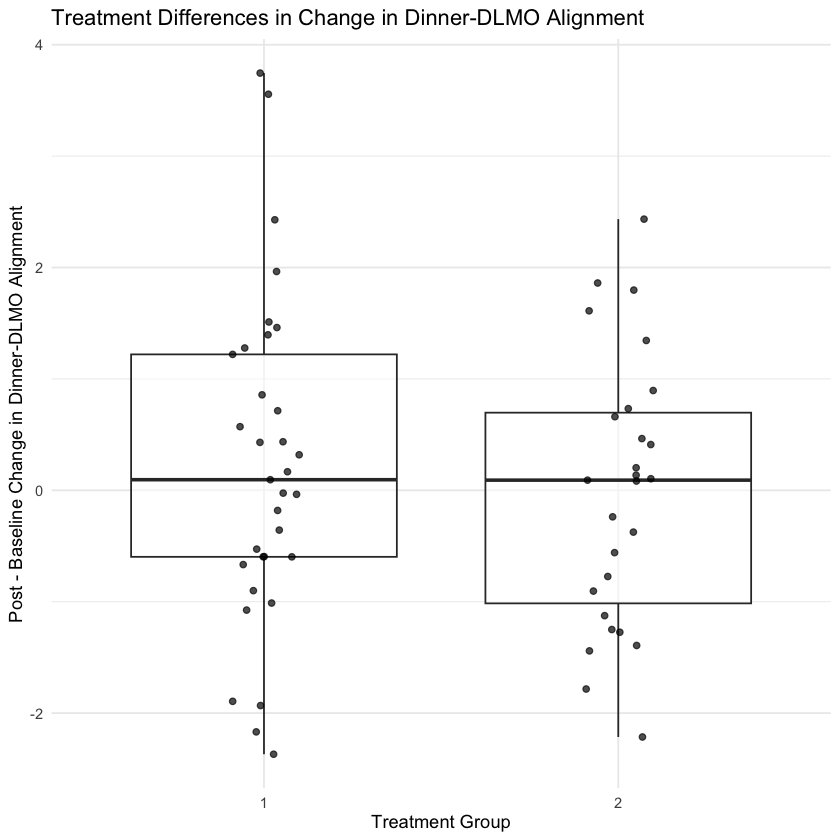

In [54]:
# Visualize treatment differences in change in dinner-DLMO alignment

ggplot(df_primary, aes(x = trt_factor, y = delta_dinner_dlmo)) +
  geom_boxplot(alpha = 0.5) +
  geom_jitter(width = 0.1, alpha = 0.7) +
  theme_minimal() +
  labs(
    title = "Treatment Differences in Change in Dinner-DLMO Alignment",
    x = "Treatment Group",
    y = "Post - Baseline Change in Dinner-DLMO Alignment")

`geom_smooth()` using formula = 'y ~ x'


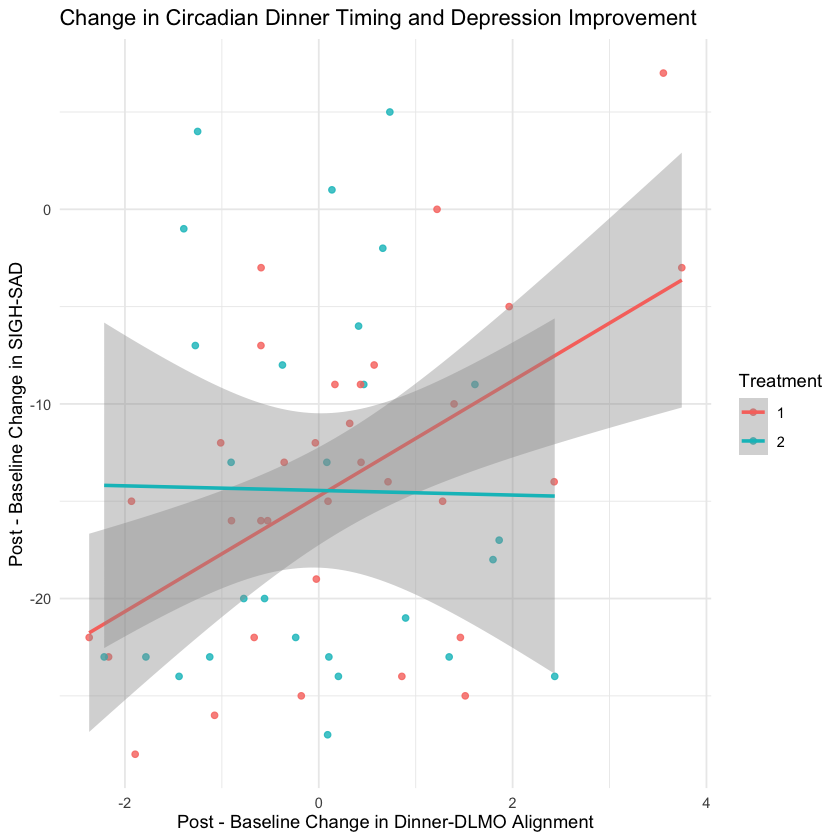

In [56]:
# Visualize mediator-outcome association

ggplot(df_primary,
  aes(x = delta_dinner_dlmo, y = delta_ss, color = trt_factor)) +
  geom_point(alpha = 0.8) +
  geom_smooth(method = "lm", se = TRUE) +
  theme_minimal() +
  labs(
    title = "Change in Circadian Dinner Timing and Depression Improvement",
    x = "Post - Baseline Change in Dinner-DLMO Alignment",
    y = "Post - Baseline Change in SIGH-SAD",
    color = "Treatment"
  )

In [57]:
# Path a: treatment predicting mediator change

model_a <- lm(delta_dinner_dlmo ~ trt_factor + dinner_dlmo_baseline + ss_baseline + Age,
  data = df_primary)

summary(model_a)
tidy(model_a)


Call:
lm(formula = delta_dinner_dlmo ~ trt_factor + dinner_dlmo_baseline + 
    ss_baseline + Age, data = df_primary)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.25755 -0.93959  0.04236  0.64464  3.13794 

Coefficients:
                     Estimate Std. Error t value Pr(>|t|)   
(Intercept)           1.20826    1.24181   0.973  0.33482   
trt_factor2          -0.21895    0.32547  -0.673  0.50393   
dinner_dlmo_baseline -0.45730    0.13250  -3.451  0.00108 **
ss_baseline          -0.03396    0.03928  -0.865  0.39104   
Age                  -0.01808    0.01256  -1.439  0.15586   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.225 on 55 degrees of freedom
Multiple R-squared:  0.2329,	Adjusted R-squared:  0.1771 
F-statistic: 4.174 on 4 and 55 DF,  p-value: 0.005052


term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1.20825867,1.24181486,0.9729781,0.33482407
trt_factor2,-0.21895393,0.32546598,-0.6727398,0.50392963
dinner_dlmo_baseline,-0.45730214,0.13249946,-3.4513509,0.00107928
ss_baseline,-0.03396191,0.03928230,-0.8645601,0.39103542
Age,-0.01807841,0.01256447,-1.4388521,0.15585927


In [58]:
# Path b and c': mediator predicting depression change controlling for treatment

model_b <- lm(delta_ss ~ delta_dinner_dlmo + trt_factor + ss_baseline + dinner_dlmo_baseline + Age,
  data = df_primary)

summary(model_b)
tidy(model_b)


Call:
lm(formula = delta_ss ~ delta_dinner_dlmo + trt_factor + ss_baseline + 
    dinner_dlmo_baseline + Age, data = df_primary)

Residuals:
    Min      1Q  Median      3Q     Max 
-14.176  -5.203  -1.239   4.017  16.976 

Coefficients:
                     Estimate Std. Error t value Pr(>|t|)   
(Intercept)           6.13170    8.09201   0.758  0.45190   
delta_dinner_dlmo     0.70813    0.87119   0.813  0.41988   
trt_factor2          -0.12441    2.11144  -0.059  0.95323   
ss_baseline          -0.77679    0.25552  -3.040  0.00364 **
dinner_dlmo_baseline -1.59661    0.94423  -1.691  0.09662 . 
Age                  -0.04908    0.08269  -0.594  0.55532   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 7.915 on 54 degrees of freedom
Multiple R-squared:  0.2693,	Adjusted R-squared:  0.2016 
F-statistic:  3.98 on 5 and 54 DF,  p-value: 0.003808


term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),6.13170265,8.09200893,0.75774789,0.45189611
delta_dinner_dlmo,0.70813185,0.87118887,0.81283390,0.41988258
trt_factor2,-0.12440589,2.11144025,-0.05891992,0.95323339
ss_baseline,-0.77679350,0.25551818,-3.04007137,0.00364319
dinner_dlmo_baseline,-1.59661040,0.94423016,-1.69091231,0.09661832
Age,-0.04907849,0.08269163,-0.59351220,0.55531642


In [59]:
# Total effect model: treatment predicting depression change without mediator

model_total <- lm(delta_ss ~ trt_factor + ss_baseline + Age,
  data = df_primary)

summary(model_total)
tidy(model_total)


Call:
lm(formula = delta_ss ~ trt_factor + ss_baseline + Age, data = df_primary)

Residuals:
    Min      1Q  Median      3Q     Max 
-11.974  -5.815  -1.309   3.650  17.738 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 12.69630    7.85586   1.616 0.111681    
trt_factor2 -0.71381    2.16182  -0.330 0.742489    
ss_baseline -0.91799    0.25643  -3.580 0.000719 ***
Age         -0.05141    0.08367  -0.614 0.541434    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 8.171 on 56 degrees of freedom
Multiple R-squared:  0.1923,	Adjusted R-squared:  0.149 
F-statistic: 4.443 on 3 and 56 DF,  p-value: 0.00718


term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),12.69629638,7.85585806,1.6161565,0.1116808176
trt_factor2,-0.71380935,2.16181690,-0.3301896,0.7424888380
ss_baseline,-0.91798971,0.25642837,-3.5799070,0.0007189091
Age,-0.05140958,0.08367338,-0.6144078,0.5414341832


In [60]:
# get path estimates 

levels(df_primary$trt_factor)

a_name <- names(coef(model_a))[str_detect(names(coef(model_a)), "trt_factor")][1]
c_name <- names(coef(model_b))[str_detect(names(coef(model_b)), "trt_factor")][1]
total_name <- names(coef(model_total))[str_detect(names(coef(model_total)), "trt_factor")][1]

a_path <- coef(model_a)[a_name]
b_path <- coef(model_b)["delta_dinner_dlmo"]
c_prime <- coef(model_b)[c_name]
c_total <- coef(model_total)[total_name]

indirect_effect <- a_path * b_path

mediation_summary <- data.frame(
  Effect = c("a path", "b path", "Indirect effect", "Direct effect c'", "Total effect c"),
  Estimate = c(a_path, b_path, indirect_effect, c_prime, c_total))

mediation_summary

[1] "1" "2"

Effect,Estimate
<chr>,<dbl>
a path,-0.2189539
b path,0.7081318
Indirect effect,-0.1550483
Direct effect c',-0.1244059
Total effect c,-0.7138094


In [67]:
# Bootstrap indirect effect

mediation_boot <- function(data, indices) {
  
  d <- data[indices, ]
  
  a_model <- lm(delta_dinner_dlmo ~ trt_factor + dinner_dlmo_baseline + ss_baseline + Age, 
                data = d)
  
  b_model <- lm(delta_ss ~ delta_dinner_dlmo + trt_factor + ss_baseline + dinner_dlmo_baseline + Age,
    data = d)
  
  a_name <- names(coef(a_model))[str_detect(names(coef(a_model)), "trt_factor")][1]
  
  a <- coef(a_model)[a_name]
  b <- coef(b_model)["delta_dinner_dlmo"]
  
  return(a * b)}

set.seed(101)

boot_results <- boot(data = df_primary, statistic = mediation_boot, R = 1000)

boot_results
boot.ci(boot_results, type = "perc")


ORDINARY NONPARAMETRIC BOOTSTRAP


Call:
boot(data = df_primary, statistic = mediation_boot, R = 1000)


Bootstrap Statistics :
      original      bias    std. error
t1* -0.1550483 -0.01485301   0.3824842

BOOTSTRAP CONFIDENCE INTERVAL CALCULATIONS
Based on 1000 bootstrap replicates

CALL : 
boot.ci(boot.out = boot_results, type = "perc")

Intervals : 
Level     Percentile     
95%   (-1.0731,  0.4118 )  
Calculations and Intervals on Original Scale

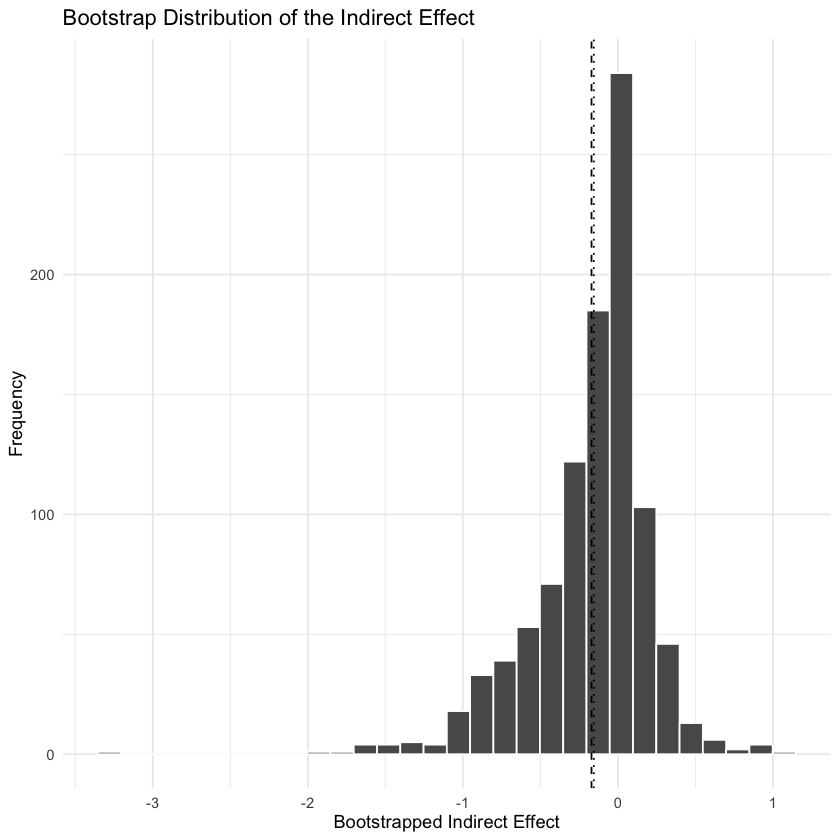

In [68]:
# Plot bootstrap

boot_df <- data.frame(indirect_effect = boot_results$t[, 1])

ggplot(boot_df, aes(x = indirect_effect)) +
  geom_histogram(color = "white", bins = 30) +
  geom_vline(xintercept = mean(boot_df$indirect_effect), linetype = "dashed") +
  geom_vline(xintercept = indirect_effect, linetype = "dotted") +
  theme_minimal() +
  labs(
    title = "Bootstrap Distribution of the Indirect Effect",
    x = "Bootstrapped Indirect Effect",
    y = "Frequency")

## Clock Time Model (Secondary_)

In [69]:
# Complete dataset for clock-time model

df_clock <- df %>%
  drop_na(trt_factor, delta_dinner_clock, delta_ss, dinner_clock_baseline, ss_baseline, Age)

dim(df_clock)
table(df_clock$trt_factor)

# more people if clock only (no DLMO needed) - good for mediation n 

[1] 97 25


 1  2 
48 49 

In [70]:
# Clock time path a

model_a_clock <- lm(delta_dinner_clock ~ trt_factor + dinner_clock_baseline + ss_baseline + Age,
  data = df_clock)

summary(model_a_clock)
tidy(model_a_clock)


Call:
lm(formula = delta_dinner_clock ~ trt_factor + dinner_clock_baseline + 
    ss_baseline + Age, data = df_clock)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.91990 -0.46781 -0.01043  0.41694  2.19784 

Coefficients:
                       Estimate Std. Error t value Pr(>|t|)    
(Intercept)            6.743406   1.845841   3.653  0.00043 ***
trt_factor2           -0.053673   0.150423  -0.357  0.72205    
dinner_clock_baseline -0.296650   0.095392  -3.110  0.00249 ** 
ss_baseline           -0.019286   0.015885  -1.214  0.22780    
Age                   -0.009476   0.005390  -1.758  0.08204 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.7377 on 92 degrees of freedom
Multiple R-squared:  0.135,	Adjusted R-squared:  0.0974 
F-statistic:  3.59 on 4 and 92 DF,  p-value: 0.009132


term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),6.743406057,1.845841225,3.6532969,0.0004302113
trt_factor2,-0.053672989,0.150423493,-0.3568125,0.7220492374
dinner_clock_baseline,-0.296649568,0.095392227,-3.1097876,0.0024924844
ss_baseline,-0.019286379,0.015884638,-1.2141529,0.2277968465
Age,-0.009476347,0.005389817,-1.7581944,0.0820401157


In [71]:
# Clock time path b and c-prime

model_b_clock <- lm(delta_ss ~ delta_dinner_clock + trt_factor + ss_baseline + dinner_clock_baseline + Age,
  data = df_clock)

summary(model_b_clock)
tidy(model_b_clock)


Call:
lm(formula = delta_ss ~ delta_dinner_clock + trt_factor + ss_baseline + 
    dinner_clock_baseline + Age, data = df_clock)

Residuals:
    Min      1Q  Median      3Q     Max 
-12.452  -5.466  -1.649   4.843  19.396 

Coefficients:
                      Estimate Std. Error t value Pr(>|t|)    
(Intercept)           20.63995   20.95909   0.985   0.3273    
delta_dinner_clock     1.89664    1.10629   1.714   0.0899 .  
trt_factor2           -1.21321    1.59727  -0.760   0.4495    
ss_baseline           -0.92925    0.16990  -5.469 3.93e-07 ***
dinner_clock_baseline -0.36497    1.06409  -0.343   0.7324    
Age                   -0.07162    0.05814  -1.232   0.2212    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 7.828 on 91 degrees of freedom
Multiple R-squared:  0.335,	Adjusted R-squared:  0.2984 
F-statistic: 9.167 on 5 and 91 DF,  p-value: 4.322e-07


term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),20.63995060,20.95909228,0.9847731,3.273466e-01
delta_dinner_clock,1.89664004,1.10628726,1.7144191,8.985579e-02
trt_factor2,-1.21320717,1.59726799,-0.7595514,4.494859e-01
ss_baseline,-0.92925286,0.16989908,-5.4694401,3.934391e-07
dinner_clock_baseline,-0.36497333,1.06409150,-0.3429906,7.323966e-01
Age,-0.07162132,0.05814498,-1.2317714,2.212080e-01


In [79]:
levels(df_clock$trt_factor)

a_name <- names(coef(model_a))[str_detect(names(coef(model_a)), "trt_factor")][1]
c_name <- names(coef(model_b))[str_detect(names(coef(model_b)), "trt_factor")][1]
total_name <- names(coef(model_total))[str_detect(names(coef(model_total)), "trt_factor")][1]

a_path <- coef(model_a)[a_name]
b_path <- coef(model_b)["delta_dinner_dlmo"]
c_prime <- coef(model_b)[c_name]
c_total <- coef(model_total)[total_name]

indirect_effect <- a_path * b_path

mediation_summary_clock <- data.frame(
  Effect = c("a path", "b path", "Indirect effect", "Direct effect c'", "Total effect c"),
  Estimate = c(a_path, b_path, indirect_effect, c_prime, c_total))

mediation_summary_clock

[1] "1" "2"

Effect,Estimate
<chr>,<dbl>
a path,-0.2189539
b path,0.7081318
Indirect effect,-0.1550483
Direct effect c',-0.1244059
Total effect c,-0.7138094


In [73]:
# Bootstrap clock time indirect effect

clock_boot <- function(data, indices) {
  
  d <- data[indices, ]
  
  a_model <- lm(delta_dinner_clock ~ trt_factor + dinner_clock_baseline + ss_baseline + Age,
    data = d)
  
  b_model <- lm(delta_ss ~ delta_dinner_clock + trt_factor + ss_baseline + dinner_clock_baseline + Age,
    data = d)
  
  a_name <- names(coef(a_model))[str_detect(names(coef(a_model)), "trt_factor")][1]
  
  a <- coef(a_model)[a_name]
  b <- coef(b_model)["delta_dinner_clock"]
  
  return(a * b)}

set.seed(101)

boot_clock <- boot(data = df_clock, statistic = clock_boot, R = 1000)

boot_clock
boot.ci(boot_clock, type = "perc")


ORDINARY NONPARAMETRIC BOOTSTRAP


Call:
boot(data = df_clock, statistic = clock_boot, R = 1000)


Bootstrap Statistics :
      original      bias    std. error
t1* -0.1017983 -0.04230788   0.3603537

BOOTSTRAP CONFIDENCE INTERVAL CALCULATIONS
Based on 1000 bootstrap replicates

CALL : 
boot.ci(boot.out = boot_clock, type = "perc")

Intervals : 
Level     Percentile     
95%   (-0.9731,  0.4546 )  
Calculations and Intervals on Original Scale

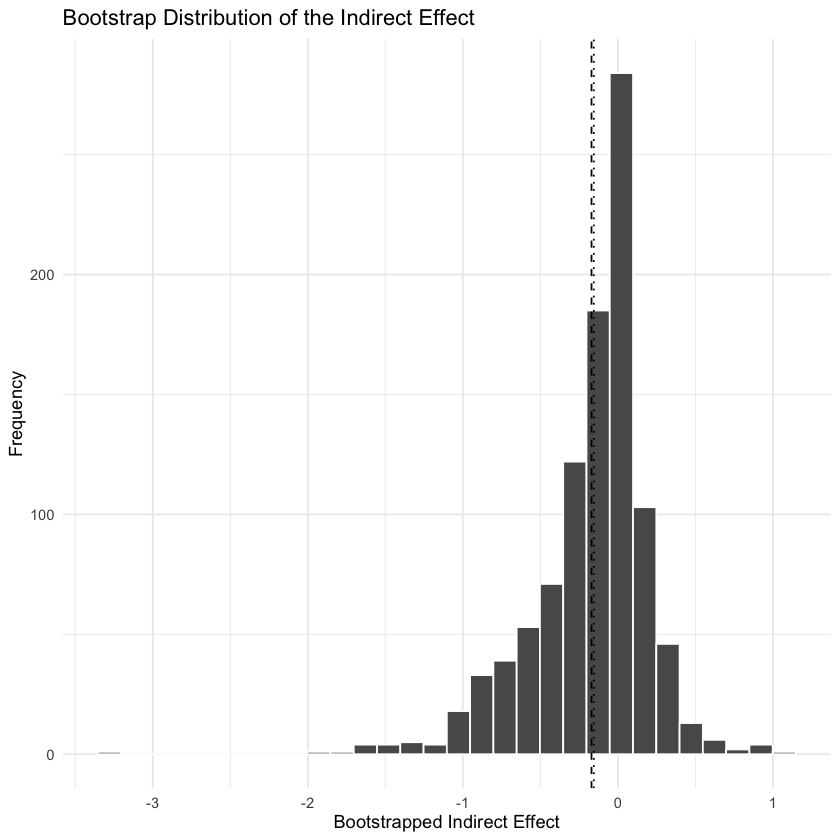

In [77]:
# Plot bootstrap distribution

clock_boot <- data.frame(
  indirect_effect = boot_results$t[, 1]
)

ggplot(clock_boot, aes(x = indirect_effect)) +
  geom_histogram(color = "white", bins = 30) +
  geom_vline(xintercept = mean(clock_boot$indirect_effect), linetype = "dashed") +
  geom_vline(xintercept = indirect_effect, linetype = "dotted") +
  theme_minimal() +
  labs(
    title = "Bootstrap Distribution of the Indirect Effect",
    x = "Bootstrapped Indirect Effect",
    y = "Frequency"
  )

`geom_smooth()` using formula = 'y ~ x'


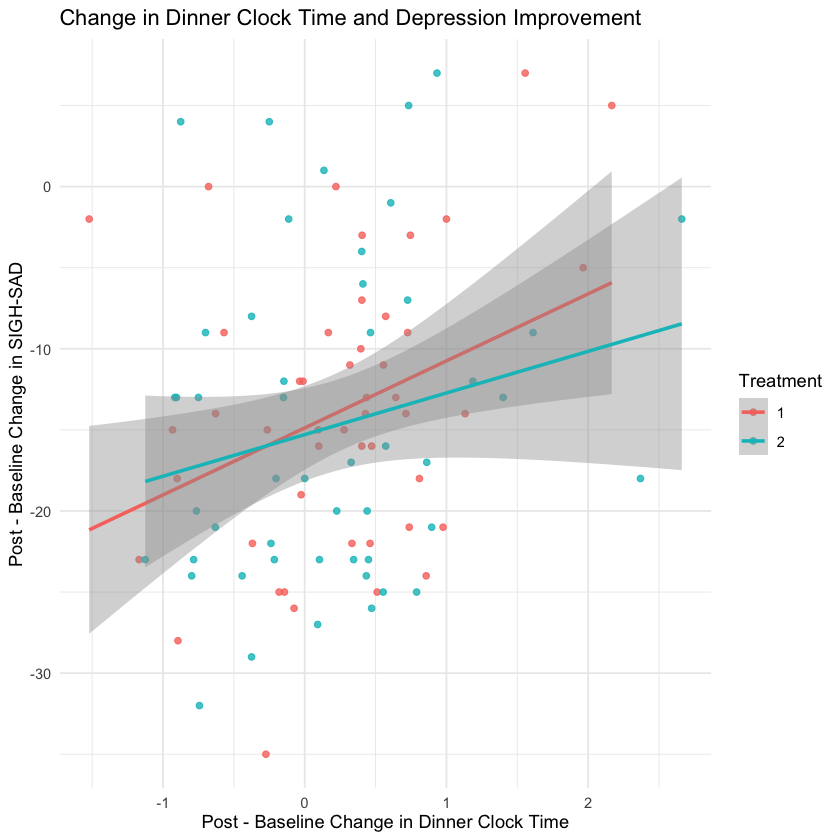

In [75]:
# Plot clock time dinner association with depression change

ggplot(df_clock,
  aes(x = delta_dinner_clock, y = delta_ss, color = trt_factor)) +
  geom_point(alpha = 0.8) +
  geom_smooth(method = "lm", se = TRUE) +
  theme_minimal() +
  labs(
    title = "Change in Dinner Clock Time and Depression Improvement",
    x = "Post - Baseline Change in Dinner Clock Time",
    y = "Post - Baseline Change in SIGH-SAD",
    color = "Treatment")

## Conclusions

Although we hypothesized that treatment-related changes in circadian dinner timing would mediate improvements in depression, our results did not support mediation. Treatment group (LT, CBT-SAD) did not predict change in alignment of dinner timing relative to DLMO, and change in alignment was not associated with change in depressive symptoms. The bootstrapped indirect effect was small and not statistically significant. However, baseline Dinner-DLMO alignment was a significant predictor of subsequent change, such that individuals with greater duration between dinner and DLMO (more misaligned) exhibited larger realignment over the course of treatment. Individuals with later dinner timing relative to DLMO (more misaligned) at baseline showed greater shifts toward earlier (more aligned) timing over treatment. These findings suggest that while circadian meal timing may be modifiable by antidepressant treatments, its role as a route by which depression changes is unclear. 

Secondary aim: 
In the model using clock time of dinner, treatment group did not predict changes in dinner timing, and the indirect effect of dinner timing on depression was not significant. While earlier shifts in dinner timing showed some greater reductions in depressive symptoms, this was not statistically significant.
